# Example Usage of `astrotrack`

In [4]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Time Array:
ts = load.timescale()
length = 3600  # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London", 51.5, 0.128], ["REACH", -30.7, -21.5]]

In [8]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=60,
    obs_lat=51.5,
    obs_lon=-0.1,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="OneWeb"
)

Processing satellites: 100%|██████████| 654/654 [00:08<00:00, 80.05satellite/s] 


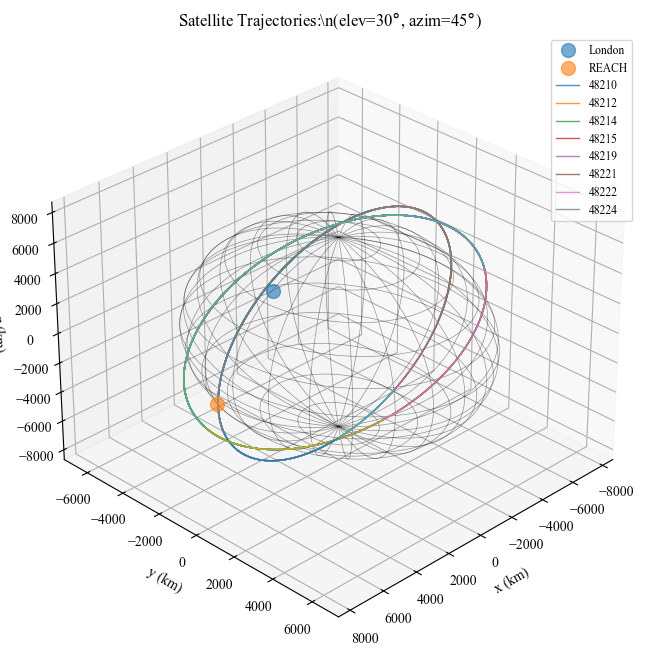

In [9]:
from astrotrack.satcon_properties import plot_satellite_trajectory

plot_satellite_trajectory(
    data,
    elev=30,
    azim=45,
    time=epochs_of_orbit,
    ref_points=ref_locations,
    show_legend=True,
    figsize=(8, 8),
    font_family="Times New Roman"
)

In [ ]:
from astrotrack.satcon_properties import plot_flyover_histogram_by_norad

plot_flyover_histogram_by_norad(
    data,
    cutoff_norad=None,
    gap_hours=1.0,
    bin_width=500,
    color="lightpink",
    font_family="Times New Roman",
    figsize=(8, 8)
)

In [ ]:
from astrotrack.satcon_properties import plot_satellite_metric

plot_satellite_metric(
    data,
    variable="Elevations",
    threshold=None,
    invert=False,
    font_family="Times New Roman",
    figsize=(8, 8)
)

In [ ]:
from astrotrack.satcon_animate import animate_trajectories

animate_trajectories(
    data,
    ref_points=ref_locations,
    duration_hours=4,
    step_seconds=60,
    start_time=datetime(2025, 6, 15, 12, 25, 8),
    output_dir=".",
    filename_prefix="animated_satellites"
)

In [ ]:
from astrotrack.satcon_properties import filter_by_norads
from astrotrack.doppler_analysis import check_doppler_resolution

subset = filter_by_norads(data, exact_id=56713)
f0_array = [110e6, 137.5e6]
check_doppler_resolution(subset, f0_array, resolution=12_000, experiment="REACH")

In [ ]:
from astrotrack.doppler_analysis import plot_doppler_shifts

plot_doppler_shifts(data, f0_array[0])